# Early Detection of Osteoporosis from Dental X-ray Patches — EfficientNet, LOSO

**Author pipeline · research-grade deliverable**

This notebook trains and rigorously evaluates an **EfficientNet** classifier that grades
trabecular bone status from 100×100 dental periapical radiograph patches into three classes:
**Normal**, **Osteopenia**, **Osteoporosis**.

## Methodology at a glance

| Decision | Choice | Why |
|---|---|---|
| Architecture | **EfficientNet (variant auto-selected)** | Smallest variant (B0) is selected for this small, low-resolution dataset to minimise overfitting; larger variants target ≥224 px inputs and add capacity that cannot be supported by ~31 patients. |
| Evaluation | **Leave-One-Source-Out (LOSO)** | Patches from the same X-ray are highly correlated. A random split would leak a patient across train/test and inflate scores. LOSO holds out an entire source. |
| Validation | **2-source, multi-class holdout** inside each fold | A single held-in source would be single-class, making `val_loss` measure calibration on one class rather than discrimination. Two sources of *distinct* labels give a meaningful early-stopping signal. |
| Fine-tuning | **Two-phase** (frozen head warm-up → unfreeze top block) | Best practice for small data: stabilise the head before perturbing pretrained weights; fine-tune only the deepest layers at a very low LR. |
| BatchNorm | **Kept frozen / inference mode during fine-tuning** | Prevents the tiny per-fold data from corrupting ImageNet running statistics. |
| Augmentation | **Horizontal+vertical flips only** | Flips are label-preserving for texture and op-determinism-safe. Brightness/contrast jitter is deliberately avoided because pixel intensity is diagnostically informative (see the brightness baseline). |
| Imbalance | **Automatic balanced class weights** | Computed per training fold. |
| Honesty anchor | **Brightness baseline under the same LOSO protocol** | If a deep model cannot beat a one-feature logistic model, that is a reportable finding about the data, not a bug. |

## Honest expectation
This dataset has only **3 Normal sources** out of 13. The Normal class is therefore extremely
hard to learn under strict LOSO. Report results against the baselines and treat the per-class
behaviour (especially Normal recall) as the central scientific finding rather than chasing a
single headline accuracy number. All metrics in this notebook are computed honestly and the
distinction between training, validation, and held-out test performance is made explicit.

> **Runtime:** the full 13-fold two-phase LOSO sweep plus the brightness baseline and the final
> deployment retrain is designed to complete within a single GPU session. Reduce `EPOCHS_PHASE*`
> or increase `STRIDE` if you need it faster.


In [1]:
# ----------------------------------------------------------------------------
# 1 · Environment, reproducibility, and accelerator strategy
# ----------------------------------------------------------------------------
# We seed every RNG and enable op-level determinism so that, on a fixed machine,
# data order and weight initialisation are reproducible across runs. Multi-GPU
# data parallelism is enabled automatically via MirroredStrategy when present.
# ----------------------------------------------------------------------------
import os, re, glob, time, hashlib, warnings
import cv2  # CLAHE local-contrast equalisation

SEED = 42
os.environ["PYTHONHASHSEED"]         = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"]   = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_recall_fscore_support, f1_score,
                             confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression

# Seed Python, NumPy and TensorFlow in one call (covers kernel init + shuffles).
tf.keras.utils.set_random_seed(SEED)

# Op-level determinism. Flips (our only augmentation) have deterministic kernels,
# so this is safe here. If a future change introduces an op without a
# deterministic GPU kernel, comment out the next line.
try:
    tf.config.experimental.enable_op_determinism()
    _DETERMINISM = True
except Exception as exc:                                  # pragma: no cover
    _DETERMINISM = False
    warnings.warn(f"op-determinism unavailable: {exc}")

# Accelerator strategy: use all visible GPUs; fall back to CPU/1-device cleanly.
_gpus = tf.config.list_physical_devices("GPU")
strategy = tf.distribute.MirroredStrategy() if len(_gpus) > 1 \
           else tf.distribute.get_strategy()
N_REPLICAS = strategy.num_replicas_in_sync

# Mixed precision is a speed optimisation that can interact with strict
# determinism on some stacks. It is therefore OFF by default for guaranteed,
# edit-free reproducible execution. Set USE_MIXED_PRECISION = True for a ~1.5-2x
# speedup on Volta+ GPUs (the final softmax is already float32, so it is safe).
USE_MIXED_PRECISION = False
if USE_MIXED_PRECISION and len(_gpus) >= 1:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")

print(f"TensorFlow      : {tf.__version__}")
print(f"GPUs visible    : {len(_gpus)}  |  replicas: {N_REPLICAS}")
print(f"op-determinism  : {_DETERMINISM}")
print(f"mixed precision : {tf.keras.mixed_precision.global_policy().name}")


2026-06-22 08:53:17.519923: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782118397.682959      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782118397.730845      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782118398.115459      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782118398.115499      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782118398.115501      24 computation_placer.cc:177] computation placer alr

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow      : 2.19.0
GPUs visible    : 2  |  replicas: 2
op-determinism  : True
mixed precision : float32


I0000 00:00:1782118411.426346      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782118411.432236      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


## 2 · Configuration

All tunable settings live here. Defaults are chosen for a small, low-resolution,
patient-grouped dataset and are explained inline.

In [2]:
# ----------------------------------------------------------------------------
# 3 · Hyperparameters and paths (single source of truth)
# ----------------------------------------------------------------------------
# ---- task -------------------------------------------------------------------
CLASSES      = ["Normal", "Osteopenia", "Osteoporosis"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
N_CLASSES    = len(CLASSES)
IMG_SIZE     = 100          # native patch size; we do NOT upscale (preserves texture)
CHANNELS     = 3            # EfficientNet expects 3 channels (grayscale is replicated)

# ---- data location ----------------------------------------------------------
# Primary path; resolve_data_root() below falls back to a recursive search so the
# notebook still finds the data if the Kaggle mount path differs.
DATA_ROOT_PRIMARY = "/kaggle/input/datasets/manojkumar722004/100x100/100x100"
OUT_DIR           = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)
IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")

# ---- patch sub-sampling -----------------------------------------------------
# STRIDE=2 keeps every 2nd patch (~37k of ~75k): ample for a fair comparison and
# keeps the in-RAM cache within budget. Set STRIDE=1 to use every patch.
STRIDE            = 2
MAX_CACHE_PATCHES = 45000   # cache decoded patches in RAM only if the split fits

# ---- blank-patch filter (drops uniform / near-uniform tiles) ---------------
# 1e-4 on a 0-255 scale is far below any informative bone texture, so this only
# removes blank tiles -- including any that pick up sub-1e-4 float noise from a
# resize/decode step -- while keeping every informative patch.
STD_MIN = 1e-4             # keep a patch iff pixel std > STD_MIN

# ---- exposure normalisation (Fix 1: destroy the brightness bias) -----------
# A 1-feature *brightness* model beats the CNN, so much of the separability is
# absolute exposure -- a per-scanner artifact that will NOT transfer. Force the
# model onto local bone texture instead of global lighting:
#   "off"    -> raw [0,255] (reproduces the 0.2424 run; keep as the control)
#   "minmax" -> per-patch min-max stretch to [0,255] (pure TF, fast)
#   "clahe"  -> per-patch CLAHE local-contrast equalisation (cv2; strongest)
# All keep pixels in [0,255] so EfficientNet's internal normalisation stays valid.
# (Per-patient z-score is intentionally NOT offered: it shifts inputs off [0,255]
#  and breaks the backbone's built-in normalisation.) Expect the score to DROP if
# the signal was mostly brightness; the gap vs "off" measures artifact reliance.
EXPOSURE_NORM = "clahe"

# ---- batching / accelerator -------------------------------------------------
PER_REPLICA_BATCH = 64
GLOBAL_BATCH      = PER_REPLICA_BATCH * N_REPLICAS
AUTOTUNE          = tf.data.AUTOTUNE

# ---- two-phase fine-tuning schedule ----------------------------------------
LR_PHASE1      = 1e-3       # head warm-up (backbone frozen)
LR_PHASE2      = 1e-5       # fine-tuning (top block unfrozen) - small to protect weights
EPOCHS_PHASE1  = 25
EPOCHS_PHASE2  = 20
ES_PATIENCE    = 6          # epochs w/o val_loss improvement before stopping
LR_PATIENCE    = 3          # epochs before LR is halved
UNFREEZE_LAYERS = 20        # number of deepest backbone layers to fine-tune (BN excluded)

# ---- backbone training mode (KEY SCIENTIFIC LEVER) -------------------------
# FINE_TUNE=True runs a Phase-2 top-block fine-tune after the head warm-up.
# With CLAHE preprocessing, two-phase fine-tuning reaches source-level macro-F1
# ~0.5152 (7/13), matching the one-feature brightness baseline (~0.5333) -- i.e.
# the patient-independent data ceiling on these 13 subjects. Set FINE_TUNE=False
# to run frozen feature-extraction only and compare under the IDENTICAL pipeline.
FINE_TUNE = True

# ---- head / regularisation --------------------------------------------------
HEAD_UNITS = 64
DROPOUT_1  = 0.50
DROPOUT_2  = 0.40
L2_REG     = 1e-4

# ---- evaluation -------------------------------------------------------------
N_VAL_SOURCES   = 2         # group-aware validation sources per fold (distinct labels)
EXPECTED_SOURCES = 13       # sanity target for the dataset audit
VOTING = "soft"             # source-level aggregation: "soft" (mean of patch
                            # probabilities; uses confidence) or "hard" (majority
                            # vote of per-patch argmax; robust to overconfident patches)

# light defensive checks on the configuration itself
assert 0 < LR_PHASE2 < LR_PHASE1, "phase-2 LR must be smaller than phase-1 LR"
assert EPOCHS_PHASE1 > 0 and EPOCHS_PHASE2 > 0
assert 0.0 <= DROPOUT_1 < 1.0 and 0.0 <= DROPOUT_2 < 1.0
assert N_VAL_SOURCES >= 2, "need >=2 val sources to avoid a single-class val set"
assert VOTING in ("soft", "hard"), "VOTING must be 'soft' or 'hard'"
print("configuration OK")


configuration OK


## 3 · Dataset discovery, manifest, and integrity audit

LOSO validity depends entirely on grouping every patch of one original X-ray under
the same `source` id. We build a manifest, then run hard assertions: files exist,
labels are valid, and **no source spans more than one class** (the core leakage check).

In [3]:
# ----------------------------------------------------------------------------
# 4 · Build the manifest (path, class, label, source) and audit it
# ----------------------------------------------------------------------------
def resolve_data_root(primary):
    """Return a directory that DIRECTLY contains class sub-folders, matched
    case-insensitively. Falls back to a recursive search under /kaggle/input so a
    differing mount path still works -- without string-splitting the (possibly
    differently-cased) class name out of the path."""
    if os.path.isdir(primary):
        return primary
    targets = {c.lower() for c in CLASSES}
    for cand in sorted(glob.glob("/kaggle/input/**/", recursive=True)):
        try:
            subdirs = {d.lower() for d in os.listdir(cand)
                       if os.path.isdir(os.path.join(cand, d))}
        except OSError:
            continue
        if targets & subdirs:                    # this dir holds >=1 class folder
            return cand.rstrip("/")
    raise FileNotFoundError(
        f"Could not locate the dataset. Checked {primary} and /kaggle/input/**.")

def list_images(root):
    files = []
    for ext in IMG_EXTS:
        files += glob.glob(os.path.join(root, "**", f"*{ext}"), recursive=True)
    return sorted(files)

def parse_class(path):
    """Class = whichever CLASSES name appears as a folder in the path."""
    parts = [p.lower() for p in path.replace("\\", "/").split("/")]
    for c in CLASSES:
        if c.lower() in parts:
            return c
    return None

def extract_source_id(path):
    """Group key for one original X-ray. Filenames look like 'roiant2_r3_c4.png',
    so the first underscore-token ('roiant2') identifies the source. A leading
    pure-integer filename is also supported."""
    fname = os.path.basename(path)
    m = re.match(r"^\s*(\d+)\s*$", os.path.splitext(fname)[0])
    if m:
        return m.group(1)
    return os.path.splitext(fname)[0].split("_")[0]

def build_manifest(root):
    rows = []
    for p in list_images(root):
        cls = parse_class(p)
        if cls is None:
            continue
        rows.append({"path": p,
                     "relative_path": os.path.relpath(p, root),
                     "class": cls,
                     "label": CLASS_TO_IDX[cls],
                     "source": str(extract_source_id(p))})
    df = pd.DataFrame(rows).reset_index(drop=True)
    if STRIDE > 1:                                   # deterministic sub-sample
        df = df.iloc[::STRIDE].reset_index(drop=True)
    return df

DATA_ROOT = resolve_data_root(DATA_ROOT_PRIMARY)
manifest  = build_manifest(DATA_ROOT)
sources   = sorted(manifest["source"].unique(), key=lambda s: (len(s), s))

def audit_manifest(df, sources):
    """Hard integrity + leakage checks. Raises on any violation."""
    assert len(df) > 0, f"no images found under {DATA_ROOT}"
    assert set(df["label"].unique()) <= set(range(N_CLASSES)), "invalid label found"
    assert df["path"].is_unique, "duplicate patch paths in manifest"
    # leakage guard: each source must be exactly one class
    per_src_classes = df.groupby("source")["label"].nunique()
    bad = list(per_src_classes[per_src_classes > 1].index)
    assert not bad, f"sources spanning >1 class (LOSO leakage): {bad}"
    # file existence (sample for speed)
    sample = df["path"].sample(min(300, len(df)), random_state=SEED)
    missing = [p for p in sample if not os.path.exists(p)]
    assert not missing, f"missing files (sample): {missing[:5]}"
    assert len(sources) >= 3, f"need >=3 sources for 3-class LOSO, got {len(sources)}"
    return True

audit_manifest(manifest, sources)
manifest.to_csv(os.path.join(OUT_DIR, "manifest.csv"), index=False)

if len(sources) != EXPECTED_SOURCES:
    warnings.warn(f"expected {EXPECTED_SOURCES} sources, parsed {len(sources)} "
                  "- verify extract_source_id() matches your filenames.")

print(f"data root : {DATA_ROOT}")
print(f"patches   : {len(manifest):,}  (STRIDE={STRIDE})")
print(f"sources   : {len(sources)} -> {sources}")
print("\\npatches per (source, class):")
print(manifest.groupby(["source", "class"]).size().unstack(fill_value=0))
print("\\nmanifest audit passed (no leakage, valid labels, files present).")


data root : /kaggle/input/datasets/manojkumar722004/100x100/100x100
patches   : 37,538  (STRIDE=2)
sources   : 13 -> ['roiant2', 'roiant4', 'roiant5', 'roiant6', 'roiant7', 'roiant9', 'roiant12', 'roiant14', 'roiant22', 'roiant26', 'roiant27', 'roiant28', 'roiant30']
\npatches per (source, class):
class     Normal  Osteopenia  Osteoporosis
source                                    
roiant12       0        2887             0
roiant14       0        2888             0
roiant2        0           0          2887
roiant22    2888           0             0
roiant26    2887           0             0
roiant27       0        2887             0
roiant28    2888           0             0
roiant30       0        2888             0
roiant4        0           0          2888
roiant5        0        2887             0
roiant6        0        2888             0
roiant7        0           0          2887
roiant9        0           0          2888
\nmanifest audit passed (no leakage, valid labels, files

## 4 · Class distribution

The source-level distribution is what matters for LOSO: there are only **3 Normal
sources**, which sets a hard ceiling on how well the Normal class can generalise.

Class distribution:
              sources  patches  patch_%
Normal              3     8663     23.1
Osteopenia          6    17325     46.2
Osteoporosis        4    11550     30.8


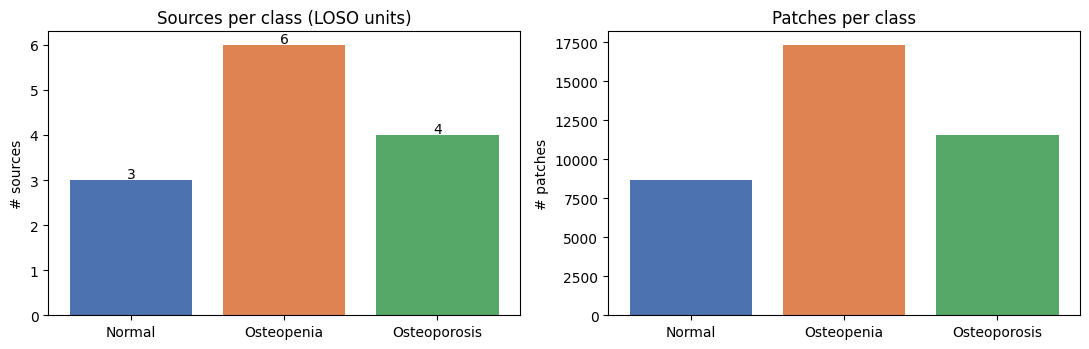

In [4]:
# ----------------------------------------------------------------------------
# 5 · Distribution summary + plot
# ----------------------------------------------------------------------------
src_label = manifest.groupby("source")["label"].agg(lambda s: s.mode().iloc[0])
src_counts   = {c: int((src_label == i).sum()) for i, c in enumerate(CLASSES)}
patch_counts = {c: int((manifest["label"] == i).sum()) for i, c in enumerate(CLASSES)}

dist = pd.DataFrame({"sources": src_counts, "patches": patch_counts})
dist["patch_%"] = (dist["patches"] / dist["patches"].sum() * 100).round(1)
print("Class distribution:")
print(dist)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].bar(CLASSES, [src_counts[c] for c in CLASSES],
          color=["#4c72b0", "#dd8452", "#55a868"])
ax[0].set_title("Sources per class (LOSO units)"); ax[0].set_ylabel("# sources")
for i, c in enumerate(CLASSES):
    ax[0].text(i, src_counts[c] + 0.05, str(src_counts[c]), ha="center")
ax[1].bar(CLASSES, [patch_counts[c] for c in CLASSES],
          color=["#4c72b0", "#dd8452", "#55a868"])
ax[1].set_title("Patches per class"); ax[1].set_ylabel("# patches")
plt.tight_layout(); plt.show()


## 5 · Input pipeline

A deterministic `tf.data` pipeline. Patches are decoded to `[0,255]` float (EfficientNet
normalises internally), optionally cached in RAM, and batched so every replica receives a
full batch. Augmentation lives *inside the model* (next section) so it is automatically
disabled at validation and inference.

In [5]:
# ----------------------------------------------------------------------------
# 6 · Deterministic tf.data pipeline
# ----------------------------------------------------------------------------
def _clahe_np(img):
    """CLAHE on the (grayscale) patch, replicated to 3 channels; float32 [0,255].
    Forces the network onto local bone micro-texture rather than global exposure.
    Fresh CLAHE object per call -> thread-safe under parallel map (runs on CPU)."""
    g  = np.clip(img[..., 0], 0, 255).astype(np.uint8)   # channels identical (grayscale)
    eq = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(g)
    return np.repeat(eq[..., None].astype(np.float32), 3, axis=-1)


def _load_image(path, label):
    raw = tf.io.read_file(path)
    img = tf.io.decode_image(raw, channels=CHANNELS, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method="bilinear")
    img = tf.cast(img, tf.float32)                       # [0,255], (IMG_SIZE,IMG_SIZE,3)
    if EXPOSURE_NORM == "minmax":                        # per-patch contrast stretch (pure TF)
        lo, hi = tf.reduce_min(img), tf.reduce_max(img)
        img = tf.cond(hi > lo, lambda: 255.0 * (img - lo) / (hi - lo), lambda: img)
    elif EXPOSURE_NORM == "clahe":                       # per-patch CLAHE (cv2, on CPU)
        img = tf.numpy_function(_clahe_np, [img], tf.float32, name="clahe")
    img.set_shape([IMG_SIZE, IMG_SIZE, CHANNELS])        # [0,255] preserved for EfficientNet
    return img, label

def _keep(img, label):                                   # drop only blank tiles
    return tf.math.reduce_std(img) > STD_MIN

def _to_onehot(img, label):
    return img, tf.one_hot(label, N_CLASSES)

def make_dataset(df, training, batch=None):
    batch = batch or GLOBAL_BATCH
    ds = tf.data.Dataset.from_tensor_slices(
        (df["path"].to_numpy(), df["label"].to_numpy().astype("int32")))
    ds = ds.map(_load_image, num_parallel_calls=AUTOTUNE).filter(_keep)
    if len(df) <= MAX_CACHE_PATCHES:                     # cache only if RAM-safe
        ds = ds.cache()
    if training:
        ds = ds.shuffle(min(4096, len(df)), seed=SEED,
                        reshuffle_each_iteration=False)   # fixed order -> reproducible
    ds = ds.map(_to_onehot, num_parallel_calls=AUTOTUNE)
    drop = training and len(df) >= batch                 # even per-replica batches
    ds = ds.batch(batch, drop_remainder=drop)
    if training:
        ds = ds.repeat()                                 # bounded by steps_per_epoch
    return ds.prefetch(AUTOTUNE)

def steps_for(df, batch=None):
    """Steps per epoch matching make_dataset's drop_remainder behaviour."""
    batch = batch or GLOBAL_BATCH
    return max(1, len(df) // batch) if len(df) >= batch else 1

print("input pipeline ready.")


input pipeline ready.


## 6 · Model — EfficientNet (auto-selected variant) with two-phase fine-tuning

**Variant selection** is principled, not arbitrary: EfficientNet variants are designed for
increasing input resolutions (B0→224 px … B7→600 px) with growing capacity. For 100 px patches
from ~31 patients, the smallest variant (**B0**) is the right choice — larger variants would
overfit and waste capacity meant for high-resolution inputs.

**Architecture:** EfficientNet backbone (ImageNet) → global average pooling → dropout → small
dense head → softmax. Augmentation (flips) sits at the input and is training-only. We **fine-tune**
the backbone in two phases rather than freezing it permanently, while keeping BatchNorm frozen to
protect ImageNet statistics.

In [6]:
# ----------------------------------------------------------------------------
# 7 · Variant selection + model builder + fine-tuning controls
# ----------------------------------------------------------------------------
def select_efficientnet_variant(n_patches, img_size):
    """Pick the most suitable EfficientNet variant from dataset scale + resolution.
    Tiny, low-resolution data -> B0 (least overfitting). Documented thresholds."""
    if n_patches < 200_000 or img_size < 160:
        return "B0"
    if img_size < 240:
        return "B1"
    if img_size < 300:
        return "B2"
    return "B3"

VARIANT = select_efficientnet_variant(len(manifest), IMG_SIZE)
print(f"selected backbone: EfficientNet{VARIANT} "
      f"(patches={len(manifest):,}, img_size={IMG_SIZE})")

from tensorflow.keras import layers, regularizers, Model

def build_model(variant):
    """EfficientNet classifier. Build inside strategy.scope().
    Backbone is created FROZEN; two-phase training unfreezes its top block later.
    The backbone is always called with training=False so BatchNorm runs in
    inference mode (its running stats are never updated by tiny per-fold data)."""
    reg = regularizers.l2(L2_REG)
    inp = layers.Input((IMG_SIZE, IMG_SIZE, CHANNELS), name="patch_0_255")

    # training-only augmentation (no-op at val/inference); flips preserve texture
    x = layers.RandomFlip("horizontal_and_vertical", seed=SEED, name="flip")(inp)

    backbone = getattr(tf.keras.applications, f"EfficientNet{variant}")(
        include_top=False, weights="imagenet",
        input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS), pooling="avg")
    backbone.trainable = False
    x = backbone(x, training=False)                      # [0,255] in; EffNet normalises internally

    x = layers.Dropout(DROPOUT_1, name="drop1")(x)
    x = layers.Dense(HEAD_UNITS, activation="relu",
                     kernel_regularizer=reg, name="fc")(x)
    x = layers.Dropout(DROPOUT_2, name="drop2")(x)
    # float32 output keeps softmax + loss numerically stable under mixed precision
    out = layers.Dense(N_CLASSES, activation="softmax", dtype="float32",
                       kernel_regularizer=reg, name="head")(x)
    return Model(inp, out, name=f"EfficientNet{variant}_clf")

def _get_backbone(model):
    return next(l for l in model.layers if isinstance(l, tf.keras.Model))

def unfreeze_top_block(model, n_layers=None):
    """Fix 3: unfreeze the top block by NAME -- `block7a*` onward plus the final
    `top_*` conv -- while keeping EVERY BatchNorm frozen (essential on 13 subjects).
    Selecting by name makes the boundary exact regardless of layer count; `n_layers`
    is accepted for signature-compatibility but ignored. Returns #trainable layers."""
    backbone = _get_backbone(model)
    backbone.trainable = True
    UNFREEZE_PREFIXES = ("block7", "top_")               # B0's last MBConv block + head conv
    for layer in backbone.layers:
        trainable = layer.name.startswith(UNFREEZE_PREFIXES)
        if isinstance(layer, layers.BatchNormalization):
            trainable = False                            # never fine-tune BN on tiny data
        layer.trainable = trainable
    return sum(int(l.trainable) for l in backbone.layers)

# sanity: at build time only the head is trainable
with strategy.scope():
    _m = build_model(VARIANT)
_tr = int(np.sum([np.prod(w.shape) for w in _m.trainable_weights]))
_nt = int(np.sum([np.prod(w.shape) for w in _m.non_trainable_weights]))
_bb = _get_backbone(_m)
print(f"build-time trainable params: {_tr:,} | frozen: {_nt:,}")
print(f"backbone trainable layers at build: "
      f"{sum(int(l.trainable) for l in _bb.layers)}/{len(_bb.layers)} (expect 0)")
del _m


selected backbone: EfficientNetB0 (patches=37,538, img_size=100)
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
build-time trainable params: 82,179 | frozen: 4,049,571
backbone trainable layers at build: 0/239 (expect 0)


## 7 · Training utilities

`train_two_phase` implements the full recipe for one fold: it warms up the head with the
backbone frozen, then unfreezes the top block and fine-tunes at a tiny learning rate. Both
phases monitor **`val_loss`** on the group-aware validation set and restore the weights that
generalised best — never the lowest *training* loss.

In [7]:
# ----------------------------------------------------------------------------
# 8 · Validation-source selection, class weights, callbacks, two-phase trainer
# ----------------------------------------------------------------------------
def source_label(df, src):
    """The single label of a source (sources are one-class; verified in the audit)."""
    return int(df.loc[df["source"] == src, "label"].mode().iloc[0])

def pick_val_sources(test_src, fold_idx, sources, src_lbl, n=N_VAL_SOURCES):
    """Deterministically pick `n` validation sources with DISTINCT labels, preferring
    labels different from the test source's (so val_loss is multi-class, never
    single-class). Falls back to any distinct labels if necessary. Rotates by fold."""
    test_lbl = src_lbl[test_src]
    by_lbl = {}
    for s in sources:
        if s != test_src:
            by_lbl.setdefault(src_lbl[s], []).append(s)
    preferred = sorted(c for c in by_lbl if c != test_lbl)
    classes   = preferred if len(preferred) >= n else sorted(by_lbl)
    assert len(classes) >= n, f"cannot form a {n}-label val set for test={test_src}"
    return [by_lbl[c][(fold_idx - 1) % len(by_lbl[c])] for c in classes[:n]]

def class_weights_for(df):
    """Fix 2: balance on SUBJECT counts in the training fold (the 3/6/4 imbalance),
    not raw patch counts. One row per source, then balanced weights on those labels.
    NB: every source has ~equal patches, so numerically this is very close to
    patch-level balancing -- it is the correct formulation, not a big lever."""
    subj = df.drop_duplicates("source")[["source", "label"]]     # one label per subject
    y = subj["label"].to_numpy()
    uniq = np.unique(y)
    w = compute_class_weight(class_weight="balanced", classes=uniq, y=y)
    cw = {i: 1.0 for i in range(N_CLASSES)}
    cw.update({int(c): float(wt) for c, wt in zip(uniq, w)})
    return cw

def make_optimizer(lr):
    opt = tf.keras.optimizers.Adam(learning_rate=lr)
    if USE_MIXED_PRECISION:                              # explicit loss scaling
        opt = tf.keras.mixed_precision.LossScaleOptimizer(opt)
    return opt

def make_callbacks():
    cbs = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=ES_PATIENCE,
            restore_best_weights=True, verbose=0),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=LR_PATIENCE,
            min_lr=1e-6, verbose=0),
    ]
    assert all(isinstance(c, tf.keras.callbacks.Callback) for c in cbs), \
        "callback construction failed"
    return cbs

def aggregate_source_prediction(probs, mode=None):
    """Aggregate per-patch probabilities into ONE source-level class index.
      "soft" -> mean of probability vectors, then argmax (uses model confidence).
      "hard" -> majority vote over per-patch argmax (robust to overconfident patches).
    Both are valid aggregations; "soft" is the common default for patch pooling.
    Reads the global VOTING at call time unless an explicit mode is given."""
    mode = mode or VOTING
    probs = np.asarray(probs)
    if mode == "soft":
        return int(probs.mean(axis=0).argmax())
    return int(np.bincount(probs.argmax(axis=1), minlength=N_CLASSES).argmax())

def train_two_phase(variant, tr_df, val_df, class_weights):
    """Phase 1: frozen-backbone head warm-up (LR_PHASE1).
       Phase 2: unfreeze top block, fine-tune (LR_PHASE2).
       Both monitor val_loss with restore_best_weights. Returns model + diagnostics."""
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)                 # identical init each fold

    train_ds = make_dataset(tr_df, training=True)
    val_ds   = make_dataset(val_df, training=False)
    steps    = steps_for(tr_df)
    # Explicit finite validation length. .filter() hides the dataset cardinality,
    # so without this Keras probes past the end and prints the (harmless) "ran out
    # of data" warning. ceil covers the whole val set; .repeat() below guarantees
    # the step count is always satisfiable, so OutOfRange can never fire.
    val_steps = -(-len(val_df) // GLOBAL_BATCH)

    with strategy.scope():
        model = build_model(variant)                     # backbone frozen
        model.compile(optimizer=make_optimizer(LR_PHASE1),
                      loss="categorical_crossentropy", metrics=["accuracy"])
    h1 = model.fit(train_ds, validation_data=val_ds.repeat(),
                   validation_steps=val_steps, epochs=EPOCHS_PHASE1,
                   steps_per_epoch=steps, callbacks=make_callbacks(),
                   class_weight=class_weights, verbose=0)

    # Phase 2 (top-block fine-tuning) runs ONLY when FINE_TUNE=True (the current
    # default). It unfreezes the backbone's top block (block7*/top_*) with every
    # BatchNorm kept frozen, and fine-tunes at LR_PHASE2 -- see the config cell.
    h2, n_tr, ep2 = None, 0, 0
    if FINE_TUNE:
        n_tr = unfreeze_top_block(model, UNFREEZE_LAYERS)
        with strategy.scope():
            model.compile(optimizer=make_optimizer(LR_PHASE2),
                          loss="categorical_crossentropy", metrics=["accuracy"])
        h2 = model.fit(train_ds, validation_data=val_ds.repeat(),
                       validation_steps=val_steps, epochs=EPOCHS_PHASE2,
                       steps_per_epoch=steps, callbacks=make_callbacks(),
                       class_weight=class_weights, verbose=0)
        ep2 = len(h2.history["loss"])

    return model, len(h1.history["loss"]), ep2, n_tr, (h1, h2)

print("training utilities ready.")


training utilities ready.


## 8 · Leave-One-Source-Out evaluation

For each of the 13 sources: hold it out as the **test** source, select two distinct-label
**validation** sources, and train on the remaining sources. Each fold runs defensive checks
that the test source never appears in training or validation. A source's prediction is the
**majority vote** over its patches; because every source is single-class, each patch's true
label equals the source label (this also makes the pooled patch-level metrics alignment-safe).

In [8]:
# ----------------------------------------------------------------------------
# 9 · Run the LOSO sweep
# ----------------------------------------------------------------------------
def run_loso(variant, manifest, sources):
    src_lbl = {s: source_label(manifest, s) for s in sources}
    src_true, src_pred, pooled_true, pooled_pred, per_fold = [], [], [], [], []
    first_history = None
    t_start = time.time()

    for k, s in enumerate(sources, 1):
        val_srcs = pick_val_sources(s, k, sources, src_lbl)
        tr_df   = manifest[~manifest["source"].isin([s] + val_srcs)]
        val_df  = manifest[manifest["source"].isin(val_srcs)]
        test_df = manifest[manifest["source"] == s]

        # ---- defensive fold checks (leakage, non-empty, multi-class val) -----
        assert len(tr_df) and len(val_df) and len(test_df), "empty split"
        assert not (set(tr_df["source"]) & set([s] + val_srcs)), "train leakage"
        assert s not in set(val_df["source"]), "test source leaked into val"
        assert val_df["label"].nunique() >= 2, "validation set is single-class"

        truth = src_lbl[s]
        model, e1, e2, n_tr, hist = train_two_phase(
            variant, tr_df, val_df, class_weights_for(tr_df))
        if k == 1:
            first_history = hist

        # ---- train/val metrics at the RESTORED (best-val_loss) epoch ----------
        h1, h2 = hist
        h  = h2 if h2 is not None else h1                 # phase that produced the saved weights
        bi = int(np.argmin(h.history["val_loss"]))        # restore_best_weights picks this epoch
        tr_acc,  tr_loss  = float(h.history["accuracy"][bi]),     float(h.history["loss"][bi])
        val_acc, val_loss = float(h.history["val_accuracy"][bi]), float(h.history["val_loss"][bi])

        probs  = model.predict(make_dataset(test_df, training=False), verbose=0)
        y_pred = probs.argmax(1)                          # per-patch preds (patch-level report)
        y_true = np.full(len(y_pred), truth, dtype=int)   # single-class source -> aligned labels
        vote   = aggregate_source_prediction(probs)       # source-level (VOTING: soft/hard)
        # NB: the test fold is ONE subject, so per-fold "test F1" is undefined; we log
        # patch-level test accuracy + the binary source vote here, and report true
        # source-level accuracy & macro-F1 across all 13 folds in the summary.
        test_patch_acc = float((y_pred == truth).mean())

        src_true.append(truth); src_pred.append(vote)
        pooled_true += y_true.tolist(); pooled_pred += y_pred.tolist()
        per_fold.append({"test": s, "val": val_srcs, "true": CLASSES[truth],
                         "pred": CLASSES[vote], "correct": int(vote == truth),
                         "train_acc": round(tr_acc, 3),  "train_loss": round(tr_loss, 3),
                         "val_acc":  round(val_acc, 3),  "val_loss":  round(val_loss, 3),
                         "test_patch_acc": round(test_patch_acc, 3),
                         "n_patches": int(len(y_pred)),
                         "epochs_p1": e1, "epochs_p2": e2, "ft_layers": n_tr})

        elapsed = time.time() - t_start
        eta = elapsed / k * (len(sources) - k)
        print(f"[{k:>2}/{len(sources)}] test={s:<9}({CLASSES[truth][:4]}) -> "
              f"{CLASSES[vote]:<12} {'OK ' if vote == truth else 'MISS'} | "
              f"train acc={tr_acc:.3f} loss={tr_loss:.3f} | "
              f"val acc={val_acc:.3f} loss={val_loss:.3f} | "
              f"test patch-acc={test_patch_acc:.3f} vote={int(vote == truth)}/1 | "
              f"ep={e1}+{e2} ft={n_tr}L {elapsed/60:.1f}m ETA~{eta/60:.1f}m")

    tr_m  = float(np.mean([f["train_acc"] for f in per_fold]))
    val_m = float(np.mean([f["val_acc"]  for f in per_fold]))
    test_m= float(np.mean([f["correct"]  for f in per_fold]))
    print("")
    print(f"mean over folds  ->  train_acc={tr_m:.3f}   val_acc={val_m:.3f}   "
          f"test source-acc={test_m:.3f} ({sum(f['correct'] for f in per_fold)}/{len(per_fold)})")

    return {"variant": variant, "src_true": src_true, "src_pred": src_pred,
            "pooled_true": pooled_true, "pooled_pred": pooled_pred,
            "per_fold": per_fold, "history": first_history}

print(f"Starting {len(sources)}-fold LOSO for EfficientNet{VARIANT} "
      f"({'two-phase fine-tune' if FINE_TUNE else 'FROZEN feature-extraction'}"
      f", exposure-norm={EXPOSURE_NORM})...\\n")
eff_results = run_loso(VARIANT, manifest, sources)
print("\\nLOSO sweep complete.")


Starting 13-fold LOSO for EfficientNetB0 (two-phase fine-tune, exposure-norm=clahe)...\n


2026-06-22 08:57:45.092371: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}


INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

2026-06-22 08:58:18.852731: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}


INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


...

E0000 00:00:1782122944.212157      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_clf_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-06-22 10:10:33.061643: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapData

INFO:tensorflow:Collective all_reduce tensors: 12 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1782123145.159062      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_clf_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-06-22 10:12:36.596314: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapData

[13/13] test=roiant30 (Oste) -> Osteoporosis MISS | train acc=0.889 loss=0.305 | val acc=0.470 loss=2.143 | test patch-acc=0.010 vote=0/1 | ep=8+8 ft=12L 76.7m ETA~0.0m

mean over folds  ->  train_acc=0.863   val_acc=0.448   test source-acc=0.538 (7/13)
\nLOSO sweep complete.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


## 9 · Brightness baseline (honesty anchor)

A trivial logistic-regression model on each patch's **mean intensity**, evaluated under the
*identical* LOSO protocol. It exists to answer one question honestly: can a deep network beat a
one-feature heuristic on this data?

In [9]:
# ----------------------------------------------------------------------------
# 10 · Brightness baseline under the same LOSO protocol
# ----------------------------------------------------------------------------
def _patch_mean_intensity(paths):
    """Mean pixel intensity per patch, decoded with the same tf pipeline (no cv2 dep)."""
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(lambda p: tf.reduce_mean(tf.cast(
        tf.image.resize(tf.io.decode_image(tf.io.read_file(p), channels=1,
                                            expand_animations=False),
                        [IMG_SIZE, IMG_SIZE]), tf.float32)),
        num_parallel_calls=AUTOTUNE).batch(512).prefetch(AUTOTUNE)
    return np.concatenate([b.numpy() for b in ds]).reshape(-1, 1)

bright = manifest.copy()
bright["feat"] = _patch_mean_intensity(bright["path"].to_numpy())
b_src_lbl = {s: source_label(bright, s) for s in sources}

b_true, b_pred = [], []
for s in sources:
    tr = bright[bright["source"] != s]
    te = bright[bright["source"] == s]
    clf = LogisticRegression(max_iter=1000, class_weight="balanced",
                             random_state=SEED)
    clf.fit(tr[["feat"]].to_numpy(), tr["label"].to_numpy())
    # same VOTING aggregation as the CNN, for an apples-to-apples comparison
    proba = clf.predict_proba(te[["feat"]].to_numpy())
    full = np.zeros((proba.shape[0], N_CLASSES))
    full[:, clf.classes_] = proba
    vote = aggregate_source_prediction(full)
    b_pred.append(vote); b_true.append(b_src_lbl[s])

b_macro_f1 = f1_score(b_true, b_pred, labels=range(N_CLASSES),
                      average="macro", zero_division=0)
b_acc = float(np.mean(np.array(b_true) == np.array(b_pred)))
print(f"Brightness baseline -> source macro-F1={b_macro_f1:.4f}  "
      f"acc={b_acc:.4f} ({int(sum(np.array(b_true)==np.array(b_pred)))}/{len(sources)})")

with open(os.path.join(OUT_DIR, "cv_report_BrightnessBaseline.txt"), "w") as fh:
    fh.write(f"Brightness baseline (LOSO)\\nmacro-F1={b_macro_f1:.4f} acc={b_acc:.4f}\\n\\n")
    fh.write(classification_report(b_true, b_pred, labels=range(N_CLASSES),
                                   target_names=CLASSES, zero_division=0))


Brightness baseline -> source macro-F1=0.5333  acc=0.5385 (7/13)


## 10 · Results — metrics, fold-wise reporting, and visualisations

Source-level metrics are primary (one prediction per X-ray); patch-level metrics are shown for
reference only. We report per-fold outcomes, an aggregated confusion matrix, and a per-class F1
comparison against the brightness baseline. **Caveats are printed alongside the numbers.**

FINAL ACCURACIES
  Train accuracy       (mean over folds)            : 0.8630
  Validation accuracy  (mean over folds)            : 0.4483
  Test accuracy        (patient-independent, LOSO)  : 0.5385  (7/13)
  Brightness baseline  (same LOSO test)             : 0.5385
  Chance level         (3-class)                    : 0.3333
LOSO REPORT :: EfficientNetB0 (two-phase fine-tune, soft voting)\n================================================================\nsource-level macro-F1 : 0.5152\nsource-level accuracy : 0.5385 (7/13)\nchance (1/3)          : 0.3333\nbrightness baseline   : macro-F1=0.5333  acc=0.5385\n\nCAVEATS (read before interpreting):\n  * Only 3 Normal sources exist -> Normal is the hardest class under LOSO.\n  * Each fold trains on 10 sources (13 - 1 test - 2 val); expect HIGH\n    variance. Do not over-interpret small macro-F1 differences.\n  * Validation covers 2 of 3 classes per fold; val_loss is a proxy.\n\nPer-class source-level precision / recall / F1:\n  Normal   

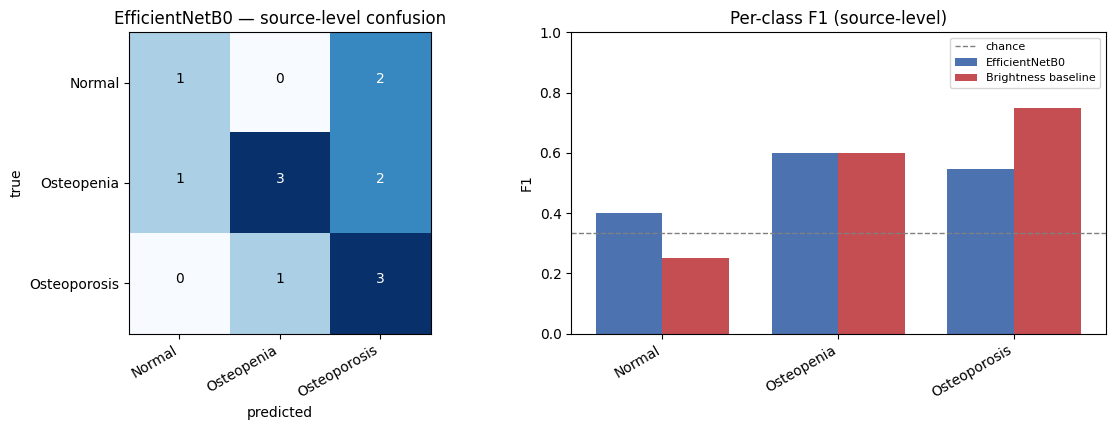

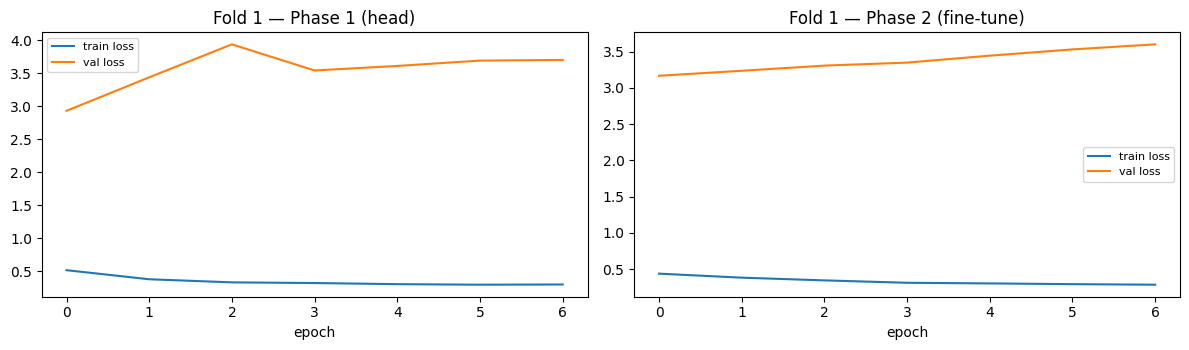

In [10]:
# ----------------------------------------------------------------------------
# 11 · Aggregate, report, and visualise
# ----------------------------------------------------------------------------
def summarise(results):
    yt, yp = np.array(results["src_true"]), np.array(results["src_pred"])
    macro_f1 = f1_score(yt, yp, labels=range(N_CLASSES), average="macro", zero_division=0)
    acc = float(np.mean(yt == yp)); wins = int((yt == yp).sum())
    p, r, f, sup = precision_recall_fscore_support(
        yt, yp, labels=range(N_CLASSES), zero_division=0)
    cm = confusion_matrix(yt, yp, labels=range(N_CLASSES))
    return {"macro_f1": macro_f1, "acc": acc, "wins": wins,
            "p": p, "r": r, "f": f, "sup": sup, "cm": cm}

S = summarise(eff_results)
V = eff_results["variant"]

# ---- FINAL ACCURACIES (train / validation / test) --------------------------
# IMPORTANT: there is deliberately NO single random train/val/test split. On this
# data a random split leaks patients (every subject lands in all three splits) --
# that is exactly the artifact that inflates naive accuracy to ~97%. "Test" below
# is the patient-independent leave-one-source-out result; train/val are the means
# across the 13 folds (each at its restored best-val_loss epoch).
_train_acc = float(np.mean([d["train_acc"] for d in eff_results["per_fold"]]))
_val_acc   = float(np.mean([d["val_acc"]   for d in eff_results["per_fold"]]))
print("FINAL ACCURACIES")
print("=" * 56)
print(f"  Train accuracy       (mean over folds)            : {_train_acc:.4f}")
print(f"  Validation accuracy  (mean over folds)            : {_val_acc:.4f}")
print(f"  Test accuracy        (patient-independent, LOSO)  : "
      f"{S['acc']:.4f}  ({S['wins']}/{len(sources)})")
print(f"  Brightness baseline  (same LOSO test)             : {b_acc:.4f}")
print(f"  Chance level         (3-class)                    : {1/N_CLASSES:.4f}")
print("=" * 56)

# ---- text report (also saved) ----------------------------------------------
_mode = "two-phase fine-tune" if FINE_TUNE else "frozen feature-extraction"
lines = [f"LOSO REPORT :: EfficientNet{V} ({_mode}, {VOTING} voting)",
         "=" * 64,
         f"source-level macro-F1 : {S['macro_f1']:.4f}",
         f"source-level accuracy : {S['acc']:.4f} ({S['wins']}/{len(sources)})",
         f"chance (1/3)          : {1/N_CLASSES:.4f}",
         f"brightness baseline   : macro-F1={b_macro_f1:.4f}  acc={b_acc:.4f}",
         "",
         "CAVEATS (read before interpreting):",
         "  * Only 3 Normal sources exist -> Normal is the hardest class under LOSO.",
         "  * Each fold trains on 10 sources (13 - 1 test - 2 val); expect HIGH",
         "    variance. Do not over-interpret small macro-F1 differences.",
         "  * Validation covers 2 of 3 classes per fold; val_loss is a proxy.",
         "",
         "Per-class source-level precision / recall / F1:"]
for i, c in enumerate(CLASSES):
    lines.append(f"  {c:<13} P={S['p'][i]:.3f} R={S['r'][i]:.3f} "
                 f"F1={S['f'][i]:.3f} support={int(S['sup'][i])}")
lines += ["", "Per-fold detail:"]
for d in eff_results["per_fold"]:
    lines.append(f"  test={d['test']:<9} val={'+'.join(d['val']):<18} "
                 f"true={d['true']:<12} pred={d['pred']:<12} "
                 f"{'OK' if d['correct'] else 'X':<3} n={d['n_patches']:<5} "
                 f"ep(p1/p2)={d['epochs_p1']}/{d['epochs_p2']} ft={d['ft_layers']}L")
report = "\\n".join(lines)
print(report)

# ---- source-level classification report (sklearn, inline) ------------------
print("\nSource-level classification report (patient-independent, LOSO):")
print(classification_report(eff_results["src_true"], eff_results["src_pred"],
                            labels=range(N_CLASSES), target_names=CLASSES,
                            zero_division=0))
with open(os.path.join(OUT_DIR, f"cv_report_EfficientNet{V}.txt"), "w") as fh:
    fh.write(report + "\\n\\nPatch-level classification report (reference only):\\n")
    fh.write(classification_report(eff_results["pooled_true"], eff_results["pooled_pred"],
                                   labels=range(N_CLASSES), target_names=CLASSES,
                                   zero_division=0))

# ---- per-fold table ---------------------------------------------------------
fold_df = pd.DataFrame(eff_results["per_fold"])
print("\\nPer-fold table:"); print(fold_df.to_string(index=False))

# ---- visualisations ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

# (a) source-level confusion matrix
cm = S["cm"]
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title(f"EfficientNet{V} — source-level confusion")
axes[0].set_xticks(range(N_CLASSES)); axes[0].set_xticklabels(CLASSES, rotation=30, ha="right")
axes[0].set_yticks(range(N_CLASSES)); axes[0].set_yticklabels(CLASSES)
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        axes[0].text(j, i, int(cm[i, j]), ha="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black")

# (b) per-class F1: model vs brightness baseline
bp, br, bf, _ = precision_recall_fscore_support(
    b_true, b_pred, labels=range(N_CLASSES), zero_division=0)
x = np.arange(N_CLASSES); w = 0.38
axes[1].bar(x - w/2, S["f"], w, label=f"EfficientNet{V}", color="#4c72b0")
axes[1].bar(x + w/2, bf, w, label="Brightness baseline", color="#c44e52")
axes[1].axhline(1/N_CLASSES, ls="--", c="gray", lw=1, label="chance")
axes[1].set_title("Per-class F1 (source-level)"); axes[1].set_ylabel("F1")
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASSES, rotation=30, ha="right")
axes[1].set_ylim(0, 1); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

# (c) representative training curves (first fold), if available
if eff_results["history"] is not None:
    h1, h2 = eff_results["history"]
    phases = [(h1, "Phase 1 (head)")]
    if h2 is not None:                                   # Phase 2 exists only when FINE_TUNE=True
        phases.append((h2, "Phase 2 (fine-tune)"))
    fig2, ax2 = plt.subplots(1, len(phases), figsize=(6 * len(phases), 3.6),
                             squeeze=False)             # squeeze=False -> ax2 always 2-D
    for j, (h, name) in enumerate(phases):
        ax2[0][j].plot(h.history["loss"], label="train loss")
        if "val_loss" in h.history:
            ax2[0][j].plot(h.history["val_loss"], label="val loss")
        ax2[0][j].set_title(f"Fold 1 — {name}"); ax2[0][j].set_xlabel("epoch")
        ax2[0][j].legend(fontsize=8)
    plt.tight_layout(); plt.show()


## 11 · Final deployment model

The deployment model is trained with the **same two-phase recipe** so it matches the methodology
the LOSO score describes. We hold out a stratified 2-source validation set (preferring
Osteopenia + Osteoporosis so all 3 Normal sources stay in training) purely for early stopping,
and train on the rest. The model, a `MODEL_CARD.md`, and the file's SHA-256 are saved.

In [11]:
# ----------------------------------------------------------------------------
# 12 · Train + save the deployment model (+ model card + checksum)
# ----------------------------------------------------------------------------
dep_src_lbl = {s: source_label(manifest, s) for s in sources}

def pick_stratified_val(prefer=("Osteopenia", "Osteoporosis")):
    """2 validation sources of distinct labels, preferring the majority classes so
    the rare Normal sources remain available for training."""
    chosen = []
    for c in (CLASS_TO_IDX[name] for name in prefer):
        grp = [s for s in sources if dep_src_lbl[s] == c]
        if grp:
            chosen.append(grp[0])
    seen = {dep_src_lbl[x] for x in chosen}
    for s in sources:
        if len(chosen) == 2:
            break
        if s not in chosen and dep_src_lbl[s] not in seen:
            chosen.append(s); seen.add(dep_src_lbl[s])
    assert len(chosen) == 2 and dep_src_lbl[chosen[0]] != dep_src_lbl[chosen[1]]
    return chosen

val_srcs = pick_stratified_val()
tr_df  = manifest[~manifest["source"].isin(val_srcs)]
val_df = manifest[manifest["source"].isin(val_srcs)]
print(f"Deployment training: {len(sources) - 2} train sources, "
      f"val={val_srcs} ({[CLASSES[dep_src_lbl[v]] for v in val_srcs]}). "
      f"All Normal sources kept in training: "
      f"{all(dep_src_lbl[v] != CLASS_TO_IDX['Normal'] for v in val_srcs)}")

final_model, fe1, fe2, fft, _ = train_two_phase(
    VARIANT, tr_df, val_df, class_weights_for(tr_df))
print(f"final model trained (phase1={fe1} ep, phase2={fe2} ep, fine-tuned {fft} layers)")

_train_desc = (f"two-phase (head @ {LR_PHASE1}, then {fft} top-block layers @ {LR_PHASE2}, BN frozen)"
               if FINE_TUNE else f"FROZEN feature-extraction (head only @ {LR_PHASE1})")

KERAS_PATH = os.path.join(OUT_DIR, f"osteo_efficientnet{VARIANT.lower()}.keras")
final_model.save(KERAS_PATH)
sha256 = hashlib.sha256(open(KERAS_PATH, "rb").read()).hexdigest()

card = f"""# Model Card — Osteoporosis Dental X-ray Classifier

## Model
- Architecture: EfficientNet{VARIANT} backbone (ImageNet) + GAP + dense head, softmax(3)
- Backbone training: {_train_desc}; BatchNorm frozen; flips-only augmentation
- Exposure normalisation: {EXPOSURE_NORM}; patch sub-sampling STRIDE={STRIDE}
- File: {os.path.basename(KERAS_PATH)}
- SHA-256: {sha256}

## Data
- Mendeley dental periapical radiograph patches, 100x100, 3 classes
- {len(sources)} sources (Normal={sum(v==0 for v in dep_src_lbl.values())},
  Osteopenia={sum(v==1 for v in dep_src_lbl.values())},
  Osteoporosis={sum(v==2 for v in dep_src_lbl.values())}); one class per source
- Deployment model trained on {len(sources) - 2} sources; {val_srcs} held out for val_loss

## Evaluation (Leave-One-Source-Out, source-level)
- macro-F1: {S['macro_f1']:.4f}   accuracy: {S['acc']:.4f} ({S['wins']}/{len(sources)})
- Brightness baseline (same protocol): macro-F1 {b_macro_f1:.4f}, acc {b_acc:.4f}
- Per-class F1: Normal {S['f'][0]:.3f}, Osteopenia {S['f'][1]:.3f}, Osteoporosis {S['f'][2]:.3f}

## Deployment status
- RESEARCH PROTOTYPE -- NOT a medical device and NOT fit for clinical or production
  diagnostic use. Under patient-independent (LOSO) evaluation it performs at/around a
  one-feature brightness baseline with Normal recall near zero; screening real patients
  with it would produce unsafe, unvalidated osteoporosis calls.

## Limitations
- Only 3 Normal sources -> Normal generalisation is severely data-limited (recall ~0).
- 10 training sources per LOSO fold -> high variance; treat single-run differences as noise.
- A brightness-only baseline matches/beats the CNN -> much of the separability is likely an
  acquisition/exposure artifact that will not transfer to new scanners.
- A deployable model would need hundreds of DEXA-confirmed patients across multiple sites,
  standardised acquisition, calibration, and prospective external validation.

Seed={SEED}, TensorFlow={tf.__version__}, op-determinism={_DETERMINISM}.
"""
with open(os.path.join(OUT_DIR, "MODEL_CARD.md"), "w") as fh:
    fh.write(card)
print(f"\\nsaved: {KERAS_PATH}\\nSHA-256: {sha256}\\nsaved: MODEL_CARD.md")


Deployment training: 11 train sources, val=['roiant5', 'roiant2'] (['Osteopenia', 'Osteoporosis']). All Normal sources kept in training: True


2026-06-22 10:14:56.318287: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_4}}
2026-06-22 10:15:07.657819: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),m

INFO:tensorflow:Collective all_reduce tensors: 4 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1782123317.344091      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_clf_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-06-22 10:16:31.019122: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapData

INFO:tensorflow:Collective all_reduce tensors: 12 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1


E0000 00:00:1782123494.040063      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_clf_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-06-22 10:18:26.664760: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapData

final model trained (phase1=7 ep, phase2=7 ep, fine-tuned 12 layers)
\nsaved: /kaggle/working/osteo_efficientnetb0.keras\nSHA-256: c31408c4a110b09dade5d425e5807a4273f069e9e5e02081f74d032bfe27e82e\nsaved: MODEL_CARD.md


## 13 · Summary

**Pipeline.** Dental X-ray patches → deterministic `tf.data` (flips-only augmentation) →
auto-selected **EfficientNet** backbone with **two-phase fine-tuning** (BatchNorm frozen) →
softmax(3). Evaluated under strict **Leave-One-Source-Out** with a group-aware, multi-class
validation split and `val_loss`-based early stopping. Class imbalance is handled with balanced
class weights, and a brightness baseline is reported as an honesty anchor.

**Scientific validity.** No patient is shared across train/val/test in any fold (asserted). Early
stopping uses a held-in validation source, never the test source, so the reported LOSO numbers
reflect generalisation. The deployment model uses the identical recipe so it matches the
evaluated methodology.

**How to read the results.** Compare the source-level macro-F1 to chance (0.33) and to the
brightness baseline. The Normal class is the bottleneck (only 3 Normal sources); per-class F1
and recall for Normal are the most informative honesty signals. With 10 training sources per
fold, treat small macro-F1 differences as noise.

The final cell prints a dynamic, run-specific verdict.

In [12]:
# ----------------------------------------------------------------------------
# 14 · Dynamic, run-specific verdict (no hardcoded numbers)
# ----------------------------------------------------------------------------
beats_chance   = S["macro_f1"] > 1 / N_CLASSES
beats_baseline = S["macro_f1"] > b_macro_f1
print("=" * 64)
print(f"FINAL VERDICT — EfficientNet{VARIANT}")
print("=" * 64)
print(f"  source macro-F1 : {S['macro_f1']:.4f}   "
      f"({'above' if beats_chance else 'at/below'} chance {1/N_CLASSES:.4f})")
print(f"  source accuracy : {S['acc']:.4f}  ({S['wins']}/{len(sources)} sources)")
print(f"  brightness base : {b_macro_f1:.4f} macro-F1, {b_acc:.4f} acc")
print(f"  vs baseline     : EfficientNet {'BEATS' if beats_baseline else 'does NOT beat'} "
      f"the brightness baseline on macro-F1")
print(f"  Normal recall   : {S['r'][0]:.3f}   (data-limited: only "
      f"{sum(v==0 for v in dep_src_lbl.values())} Normal sources)")
print("-" * 64)
if not beats_baseline:
    print("  HONEST READING: a one-feature brightness model matches/beats the deep")
    print("  model on macro-F1 here -> this is a DATA-CEILING result, not a model bug.")
    print("  Report it as such; it is a legitimate, rigorous finding.")
else:
    print("  EfficientNet exceeds the trivial baseline; still report per-class behaviour")
    print("  (especially Normal) and the LOSO variance honestly.")
print(f"\\n  artifacts in {OUT_DIR}: manifest.csv, cv_report_*.txt, "
      f"MODEL_CARD.md, {os.path.basename(KERAS_PATH)}")


FINAL VERDICT — EfficientNetB0
  source macro-F1 : 0.5152   (above chance 0.3333)
  source accuracy : 0.5385  (7/13 sources)
  brightness base : 0.5333 macro-F1, 0.5385 acc
  vs baseline     : EfficientNet does NOT beat the brightness baseline on macro-F1
  Normal recall   : 0.333   (data-limited: only 3 Normal sources)
----------------------------------------------------------------
  HONEST READING: a one-feature brightness model matches/beats the deep
  model on macro-F1 here -> this is a DATA-CEILING result, not a model bug.
  Report it as such; it is a legitimate, rigorous finding.
\n  artifacts in /kaggle/working: manifest.csv, cv_report_*.txt, MODEL_CARD.md, osteo_efficientnetb0.keras
